# ETP shipment lifecycle — model vs display

Single-load **material change ledger** for broker/DS questions: *what moved ETP50, Target 1/3, clocks, quantile refresh, or display workflow?*

**v1 cohort:** HC leadtime-isolated outliers (`leadtime_isolated_ind=1`, `primary_category=LeadtimeChange`).

Set `LOAD_ID` to override rank picker. Canonical example: rank **2** → load **9199475** (+55% avail→48hr, early_burst).


In [1]:
from IPython.display import Markdown, display

import polars as pl

from dqt import resolve_data_dir
from dqt.etp_lake import EtpLake
from dqt.etp_lifecycle import (
    COHORT_HC,
    explain_load,
    resolve_load_id,
    select_outlier_cohort,
)

# --- params ---
COHORT = COHORT_HC  # or "manual"
RANK = 2  # HC rank (9199475)
LOAD_ID = None  # set int to override rank
LOAD_ID = 9199475
MIN_SHIFT_PCT = 0.10
TOP_N = 50
QUERY_MDE = True  # True hits Snowflake

data_dir = resolve_data_dir()
lake = EtpLake(data_dir)  # lake root is $DQT_DATA_DIR/etp_lake

hc_index = select_outlier_cohort(
    cohort=COHORT,
    min_shift_pct=MIN_SHIFT_PCT,
    top_n=TOP_N,
    data_dir=data_dir,
)
display(hc_index.select(
    "hc_rank", "loadnumber", "etp50_shift_pct", "path_archetype", "primary_category"
).head(10))

LOAD_ID = resolve_load_id(cohort=COHORT, rank=RANK, load_id=LOAD_ID, data_dir=data_dir)
print(f"Explaining load {LOAD_ID} (cohort={COHORT}, rank={RANK})")


2026-09-08 18:47:26.709 | INFO     | dqt.etp_lake:resolve:175 - lake mirror reads → /mnt/dqt/etp_lake  writes → /home/azureuser/cloudfiles/code/Users/rarko/dev/etp-dqt/data/etp_lake


hc_rank,loadnumber,etp50_shift_pct,path_archetype,primary_category
u32,i32,f64,str,str
1,9199475,0.53527,"""early_burst""","""LeadtimeChange"""
2,9119169,0.43117,"""late_cliff""","""LeadtimeChange"""
3,6425193,0.42674,"""late_cliff""","""LeadtimeChange"""
4,8851323,0.416672,"""late_cliff""","""LeadtimeChange"""
5,8218454,0.414007,"""early_burst""","""LeadtimeChange"""


Explaining load 9199475 (cohort=hc_leadtime_isolated, rank=2)


In [2]:
result = explain_load(lake, LOAD_ID, query_mde=QUERY_MDE, data_dir=data_dir)
payload = result["payload"]
ledger = result["ledger"]
summary = result["summary"]

display(Markdown(f"**Executive summary**\n\n{summary['one_liner']}"))
sh = summary["endpoint_shifts"]
print(
    f"  Model ETP50: ${sh.get('etp50_avail', 0):,.0f} avail → ${sh.get('etp50_48hr', 0):,.0f} @48hr"
    f"  ({sh.get('shift_pct', 0) * 100:+.1f}%)"
)
if summary.get("movement"):
    mv = summary["movement"]
    print(
        f"  Flags: leadtime_isolated={mv.get('leadtime_isolated_ind')}"
        f" clocks_moved={mv.get('clocks_moved_ind')}"
        f" index_clock_overlap={mv.get('index_clock_overlap_ind')}"
    )


/home/azureuser/cloudfiles/code/Users/rarko/Projects/etp/etp-explanations/.venv/lib/python3.13/site-packages/snowflake/connector/vendored/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.7.0) or chardet (7.6.0)/charset_normalizer (3.5.1) doesn't match a supported version!
  warnings.warn(
2026-09-08 18:48:00.585 | INFO     | arriveds.snowflake.utils:query_sf:422 - <inline sql>: 0 rows x 5 cols in 3.99s (query_id=01c6f067-0c15-c62c-0000-94e58a5236fa)


**Executive summary**

Load 9199475: LeadtimeChange — Model ETP50 avail→48hr: $+336 (+54.8%) — drivers: model ETP +156 (+25.5%); quantile refresh: ETP +93, knn_50 +95.

  Model ETP50: $612 avail → $947 @48hr  (+54.8%)


2026-09-08 18:48:57.700 | INFO     | arriveds.snowflake.utils:query_sf:422 - <inline sql>: 0 rows x 5 cols in 4.64s (query_id=01c6f068-0c15-c282-0000-94e58a521f1a)
/mnt/batch/tasks/shared/LS_root/mounts/clusters/rarko1/code/Users/rarko/Projects/etp/etp-explanations/src/dqt/etp_timeline.py:843: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


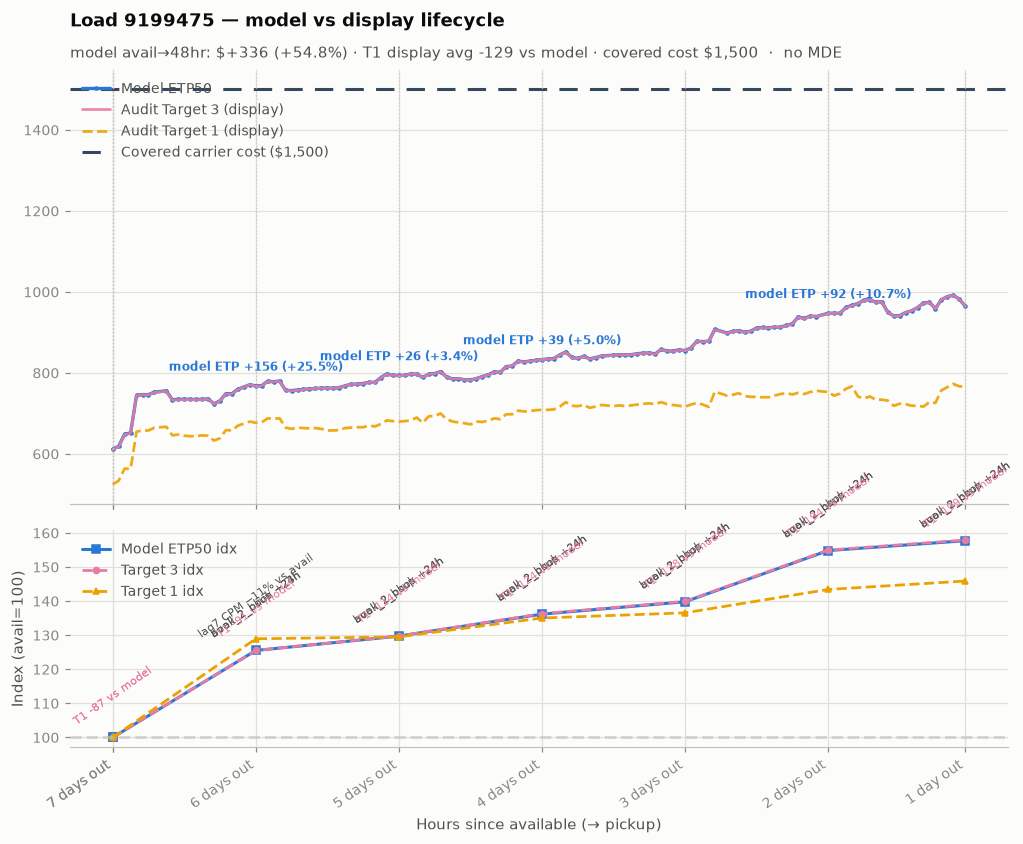

{'loadnumber': 9199475,
 'history': shape: (285, 10)
 ┌────────────┬────────────┬────────┬────────────┬───┬─────────┬────────────┬───────────┬───────────┐
 │ loadnumber ┆ snapshot_u ┆ source ┆ etp10      ┆ … ┆ target3 ┆ hours_befo ┆ hours_sin ┆ ship_mont │
 │ ---        ┆ tc         ┆ ---    ┆ ---        ┆   ┆ ---     ┆ re_pickup  ┆ ce_availa ┆ h         │
 │ i32        ┆ ---        ┆ str    ┆ f64        ┆   ┆ f64     ┆ ---        ┆ ble       ┆ ---       │
 │            ┆ datetime[n ┆        ┆            ┆   ┆         ┆ i32        ┆ ---       ┆ str       │
 │            ┆ s]         ┆        ┆            ┆   ┆         ┆            ┆ i32       ┆           │
 ╞════════════╪════════════╪════════╪════════════╪═══╪═════════╪════════════╪═══════════╪═══════════╡
 │ 9199475    ┆ 2026-07-08 ┆ model  ┆ 504.776819 ┆ … ┆ null    ┆ 168        ┆ 0         ┆ 2026-07   │
 │            ┆ 18:52:13.5 ┆        ┆            ┆   ┆         ┆            ┆           ┆           │
 │            ┆ 02430      ┆ 

In [3]:
# Timeline chart (model, T1, T3, realized cost)
lake.plot_etp_timeline(LOAD_ID, query_mde=QUERY_MDE)


In [4]:
# Material change ledger — core deliverable
pricing = ledger.filter(pl.col("is_pricing_driver"))
display_ledger = ledger.filter(~pl.col("is_pricing_driver"))

print(f"Pricing drivers: {pricing.height} rows | Display adjustments: {display_ledger.height} rows")
display(
    pricing.select(
        "hours_before_pickup",
        "metric",
        "delta_usd",
        "delta_other",
        "category",
        "confidence",
        "driver_text",
    ).head(30)
)


Pricing drivers: 31 rows | Display adjustments: 21 rows


hours_before_pickup,metric,delta_usd,delta_other,category,confidence,driver_text
i64,str,f64,f64,str,str,str
166,"""etp50""",29.958801,30.937225,"""QuantileRefresh""","""high""","""quantile refresh: ETP +30, knn…"
166,"""book_2_pkup""",null,-0.983823,"""LeadtimeChange""","""high""","""book_2_pkup −1.0h with ETP +30"""
166,"""avail_2_book""",null,0.983823,"""LeadtimeChange""","""high""","""avail_2_book +1.0h with ETP +3…"
164,"""etp50""",92.732737,95.225067,"""QuantileRefresh""","""high""","""quantile refresh: ETP +93, knn…"
164,"""book_2_pkup""",null,-0.983828,"""LeadtimeChange""","""high""","""book_2_pkup −1.0h with ETP +93"""
…,…,…,…,…,…,…
38,"""book_2_pkup""",null,-0.983945,"""LeadtimeChange""","""high""","""book_2_pkup −1.0h with ETP -26"""
38,"""avail_2_book""",null,0.983945,"""LeadtimeChange""","""high""","""avail_2_book +1.0h with ETP -2…"
25,"""book_2_pkup""",null,null,"""LeadtimeChange""","""high""","""book_2_pkup −24h"""


In [5]:
# Checkpoint table
display(payload["checkpoints"])


loadnumber,mark_hrs,mark_label,etp50,hours_before_pickup,target1,target3,book_2_pkup,avail_2_book,etp50_idx,delta_etp50_prev,target1_idx,t1_gap,target3_idx,t3_gap
i64,i64,str,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
9199475,999,"""Available""",611.812364,999,525.0,611.0,167.129651,0.5,100.0,0.0,100.0,-86.812364,100.0,-0.812364
9199475,168,"""7 days out""",611.812364,168,525.0,611.0,167.129651,0.5,100.0,-156.168932,100.0,-86.812364,100.0,-0.812364
9199475,144,"""6 days out""",767.981296,144,677.0,767.0,143.542642,23.587275,125.525625,-25.812334,128.952381,-90.981296,125.531915,-0.981296
9199475,120,"""5 days out""",793.79363,120,680.0,793.0,119.206631,47.923286,129.744621,-39.421134,129.52381,-113.79363,129.787234,-0.79363
9199475,96,"""4 days out""",833.214764,96,709.0,833.0,95.5834,71.546517,136.187958,-22.17661,135.047619,-124.214764,136.333879,-0.214764
9199475,72,"""3 days out""",855.391374,72,717.0,855.0,71.65677,95.473147,139.812698,-91.937984,136.571429,-138.391374,139.934534,-0.391374
9199475,48,"""2 days out""",947.329358,48,753.0,947.0,47.933706,119.196211,154.839852,-17.712612,143.428571,-194.329358,154.991817,-0.329358
9199475,24,"""1 day out""",965.041969,25,766.0,965.0,24.292672,142.837245,157.734957,null,145.904762,-199.041969,157.937807,-0.041969


In [6]:
# Decomposition + top hourly steps
decomp = result.get("decompose") or {}
if decomp.get("by_day") is not None:
    display(decomp["by_day"].head(15))
else:
    print("decompose by_day unavailable")
display(payload["top_steps"])


decompose by_day unavailable


loadnumber,snapshot_utc_t0,snapshot_utc_t1,delta_etp50,delta_etp10,prebook_day,lead_day,delta_hours_before_pickup,delta_hours_since_available,delta_total_charges,delta_hard_ft_cnt,delta_hard_ft_cnt_improved,delta_hard_ft_cnt_reg,delta_charge_less_dat,delta_dat_rate,delta_mean_pred_mkt_rt,delta_fuel_cost,delta_fsc,delta_lag7_cpm_x_miles,delta_ra7_cpm_x_miles,delta_book_2_pkup,delta_book_2_pkup_days,delta_avail_2_book,delta_avail_2_book_days,delta_clhp_ma,delta_clhp_pred_line,delta_clhp_pred_tot_cost,delta_knn_50,delta_knn_avg_distance,delta_loaded_miles,delta_miles_feat,ship_month,is_hyperlocal,loaded_miles
i32,datetime[ns],datetime[ns],f64,f64,i64,i64,i32,i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i16,f64,str,bool,i16
9199475,2026-07-08 21:49:18.924727,2026-07-08 22:48:20.701531,92.732737,86.332667,0,6,-1,1,0.0,0.0,0.0,0.0,104.83,0.0,-104.83,0.0,0.0,-144.322731,-28.452882,-0.983828,0.0,0.983828,0.0,null,3.020081,3.020081,95.225067,0.009399,0,0.0,"""2026-07""",false,231
9199475,2026-07-08 19:51:15.362932,2026-07-08 20:50:17.132455,29.958801,33.076841,0,6,-1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.983823,0.0,0.983823,0.0,null,0.0,0.0,30.937225,-0.0082,0,0.0,"""2026-07""",false,231
9199475,2026-07-12 22:16:57.641493,2026-07-12 23:16:06.134012,29.195013,35.800013,4,2,-1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,181.928671,-23.595739,-0.985685,0.0,0.985685,0.0,null,2.2737e-13,4.5475e-13,31.961753,-0.011254,0,0.0,"""2026-07""",false,231
9199475,2026-07-14 03:55:42.745307,2026-07-14 04:54:44.999907,-25.891821,0.0,5,1,-1,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.983945,0.0,0.983945,0.0,null,0.0,0.0,-13.192871,-0.002736,0,0.0,"""2026-07""",false,231


In [7]:
# Attribution card (broker one-liner drivers)
for i, row in enumerate(summary["attribution_card"], start=1):
    print(f"{i}. [{row['category']}] {row['driver_text']}")


1. [LeadtimeChange] model ETP +156 (+25.5%)
2. [QuantileRefresh] quantile refresh: ETP +93, knn_50 +95
3. [LeadtimeChange] model ETP +92 (+10.7%)


In [8]:
# Display adjustments (segregated)
display(display_ledger.select("hours_before_pickup", "metric", "driver_text").head(20))


hours_before_pickup,metric,driver_text
i64,str,str
999,"""display""","""T1 -87 vs model"""
168,"""display""","""T1 -87 vs model"""
166,"""target1""","""Target 1 +30 (hourly audit sna…"
164,"""target1""","""Target 1 +92 (hourly audit sna…"
144,"""target3""","""target3 +156 vs prior checkpoi…"
…,…,…
48,"""target1""","""target1 +36 vs prior checkpoin…"
48,"""t1_gap""","""T1 gap Δ -56 vs prior checkpoi…"
48,"""display""","""T1 -194 vs model"""


In [9]:
# Gallery mode — top N HC outliers (optional)
GALLERY = True
if GALLERY:
    for row in hc_index.head(5).iter_rows(named=True):
        ln = int(row["loadnumber"])
        ex = explain_load(lake, ln, data_dir=data_dir)
        print(ex["summary"]["one_liner"])
else:
    print("Set GALLERY=True to iterate top HC outliers")


Load 9199475: LeadtimeChange — Model ETP50 avail→48hr: $+336 (+54.8%) — drivers: model ETP +156 (+25.5%); quantile refresh: ETP +93, knn_50 +95.
Load 9119169: LeadtimeChange — Model ETP50 avail→48hr: $+294 (+43.2%) — drivers: model ETP +96 (+14.1%); model ETP +94 (+11.2%).
Load 6425193: LeadtimeChange — Model ETP50 avail→48hr: $+172 (+34.2%) — drivers: quantile refresh: ETP +131, knn_50 +132; model ETP +123 (+24.5%).
Load 8851323: LeadtimeChange — Model ETP50 avail→48hr: $+225 (+41.5%) — drivers: model ETP +115 (+18.6%); model ETP +99 (+14.8%).
Load 8218454: LeadtimeChange — Model ETP50 avail→48hr: $+248 (+41.4%) — drivers: model ETP +75 (+10.3%); quantile refresh: ETP +68, knn_50 +71.


## Lightning cost tracking

Ledger rows with `Lightning` in `driver_text` — CLHP endpoint, path checkpoint, and hourly moves.
Threshold defaults: **$50 abs OR 10% rel** (see `notebooks/etp-slider/lightning-cost-threshold.ipynb`).


In [10]:
lightning = result.get("lightning") or {}
print("Endpoint summary:", lightning.get("endpoint_summary"))
lt_rows = ledger.filter(pl.col("driver_text").str.contains("Lightning"))
print(f"Lightning ledger rows: {lt_rows.height}")
display(lt_rows.select(
    "hours_before_pickup", "metric", "delta_usd", "delta_other", "category", "driver_text"
).head(20))


Endpoint summary: {'clhp_pred_tot_cost_delta': -0.04911065256374059, 'clhp_pred_tot_cost_avail': 1265.4816723765985, 'clhp_pred_tot_cost_rel_pct': 3.880787342538897e-05, 'clhp_pred_line_delta': -0.04911065256396796, 'clhp_pred_line_avail': 1124.5716723765986, 'clhp_pred_line_rel_pct': 4.367054032241504e-05, 'clhp_change_ind': 0}
Lightning ledger rows: 0


hours_before_pickup,metric,delta_usd,delta_other,category,driver_text
i64,str,f64,f64,str,str
